
# Control por realimentación de estado
---

In [1]:
# Instalar paquetes necesarios (solo la primera vez)
using Pkg
Pkg.add(["ControlSystems", "ControlSystemsBase", "Plots", "LinearAlgebra", "LaTeXStrings"])

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using ControlSystems
using ControlSystemsBase
using LinearAlgebra
using Plots
using LaTeXStrings

# Configurar backend de gráficas
gr()

Plots.GRBackend()

---
## 3. Control de un robot de dos ruedas tipo pendulo inverso.

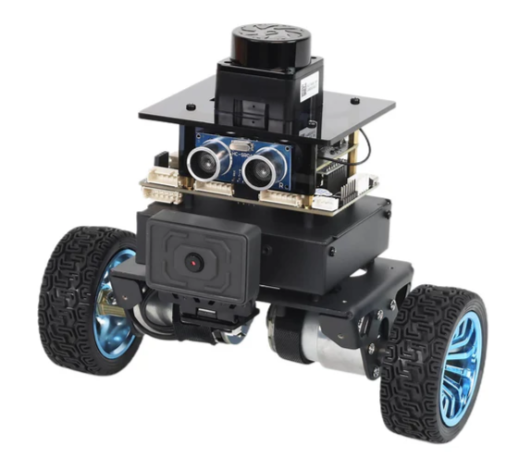

El modelo matemático de un robot de 2 ruedas (tipo péndulo inverso) linealizado en el equilibrio $x = 0$ está dado por:
$$
\begin{bmatrix}
\dot{x}_1 \\ 
\dot{x}_2 \\ 
\dot{x}_3 \\ 
\dot{x}_4
\end{bmatrix} 
= 
\begin{bmatrix}
0 & 1 & 0 & 0 \\ 
0 & -(I+ml^2)b/p & m^2gl^2/p & 0 \\ 
0 & 0 & 0 & 1 \\ 
0 & -mlb/p & mgl(M+m)/p & 0
\end{bmatrix} 
\begin{bmatrix}
x_1 \\ 
x_2 \\ 
x_3 \\ 
x_4
\end{bmatrix} 
+ 
\begin{bmatrix}
0 \\ 
(I+ml^2)/p \\ 
0 \\ 
ml/p
\end{bmatrix} 
u
$$

**Variables de estado:**
- $x_1$: Posición lineal del robot
- $x_2$: Velocidad lineal del robot
- $x_3$: Ángulo de inclinación del robot
- $x_4$: Velocidad angular en la inclinación del robot
- $u$: Torque aplicado por los motores

In [3]:
# Parámetros del robot de 2 ruedas
M_r = 1.0       # masa del chasis [kg]
m_r = 0.2       # masa de las ruedas y eje [kg]
b_r = 0.1       # coeficiente de fricción viscosa [N·m·s]
I_r = 0.0005    # momento de inercia del péndulo [kg·m²]
l_r = 0.3       # longitud del péndulo [m]
g_r = 9.8       # aceleración gravitacional [m/s²]

p_r = (M_r + m_r)*(I_r + m_r*l_r^2) - (m_r*l_r)^2


A_r = [0    1                         0                  0;
       0  -(I_r+m_r*l_r^2)*b_r/p_r  (m_r^2*g_r*l_r^2)/p_r  0;
       0    0                         0                  1;
       0  -(m_r*l_r*b_r)/p_r       m_r*g_r*l_r*(M_r+m_r)/p_r  0]

B_r = [0;
       (I_r + m_r*l_r^2)/p_r;
       0;
       m_r*l_r/p_r]

C_r = Matrix{Float64}(I, 4, 4)
D_r = zeros(4, 1)

robot_segway = ss(A_r, B_r, C_r, D_r)

println("\nA del robot:")
display(A_r)
println("\nValores propios del robot (lazo abierto):")
display(eigvals(A_r))


A del robot:


4×4 Matrix{Float64}:
 0.0   1.0         0.0      0.0
 0.0  -0.0994624   1.89677  0.0
 0.0   0.0         0.0      1.0
 0.0  -0.322581   37.9355   0.0


Valores propios del robot (lazo abierto):


4-element Vector{Float64}:
 -6.167359232527252
 -0.0833303804321428
  0.0
  6.151227247367996

---
## Actividad 1: Controlador por realimentación de estado para el robot segway

Aqui hacemos un controlador LQR

In [40]:

Q = diagm([100.0, 1.0, 1.0, 1.0])
R = diagm([1])
K = lqr(Continuous, A_r, B_r, Q, R)

println("K  = ", K)


K  = [-10.0000000000001 -8.495135802999794 45.79946952389612 7.8401689480523284]


kr robot = -10.0


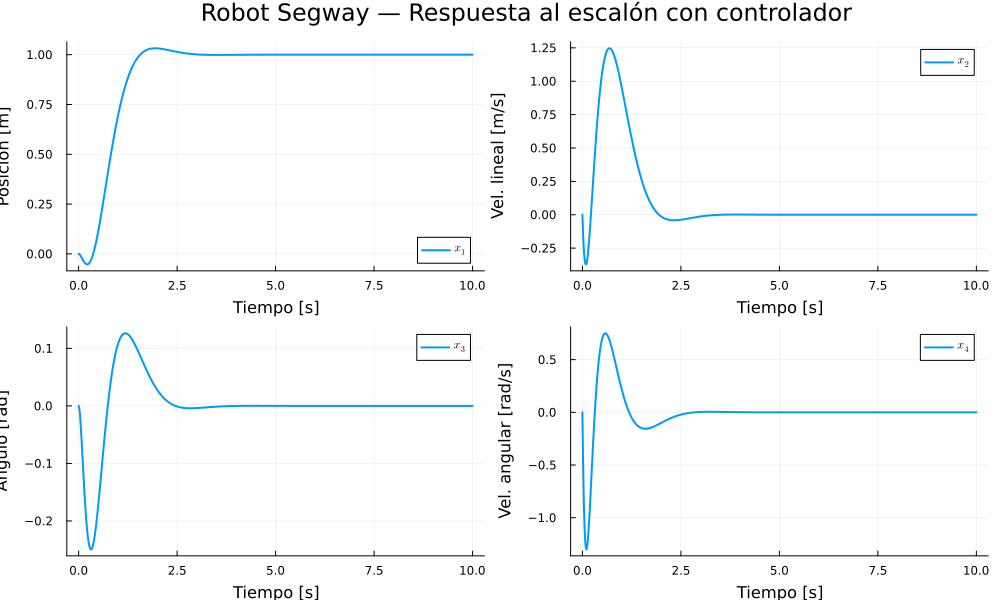

In [39]:
# Controlador con seguimiento de posición x1

C1_r = [1.0 0.0 0.0 0.0]   # salida: posición x1
kr = -1/(C_r * inv(A_r - B_r*K) * B_r)[1]

println("kr robot = ", round(kr, digits=4))

robot_lc = ss(A_r - B_r*K, B_r*kr, C_r, D_r)

# Respuesta al escalón (posición)
t_r = 0:0.01:10
ref_r = ones(1, length(t_r))
Y_r, t_r_out, X_r = lsim(robot_lc, ref_r, t_r)

labels_r = [L"x_1" L"x_2" L"x_3" L"x_4"]
ylabels_r = ["Posición [m]" "Vel. lineal [m/s]" "Ángulo [rad]" "Vel. angular [rad/s]"]

p_rob = plot(layout=(2,2), size=(1000,600),
             suptitle="Robot Segway — Respuesta al escalón con controlador")
for i in 1:4
    plot!(p_rob[i], t_r_out, Y_r[i,:],
          label=labels_r[i], xlabel="Tiempo [s]", ylabel=ylabels_r[i], lw=2)
end
display(p_rob)

## Señal de control en el robot

Máxima señal de control |u|_max = 10.0 [N·m]


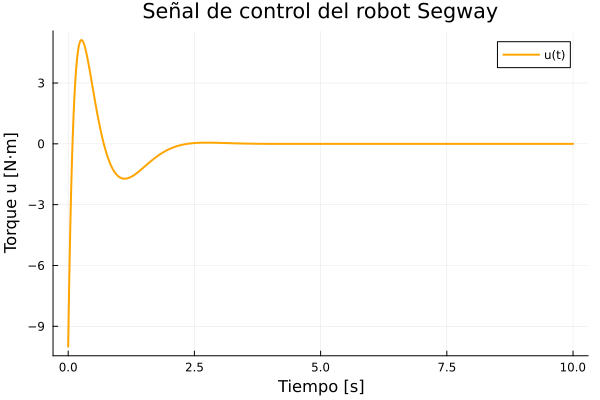

In [23]:
# Señal de control del robot
r_val = 1.0
u_robot = kr * r_val .- (K * X_r)

println("Máxima señal de control |u|_max = ", round(maximum(abs.(u_robot)), digits=4), " [N·m]")

plot(t_r_out, u_robot[1,:],
     xlabel="Tiempo [s]", ylabel="Torque u [N·m]",
     title="Señal de control del robot Segway",
     label="u(t)", lw=2, color=:orange)

---
## 4. Filtro de Kalman — Estimación de estados con ruido en mediciones

El **Filtro de Kalman** es un observador óptimo que minimiza la varianza del error de estimación cuando el sistema está sujeto a:

- **Ruido de proceso** $w(t) \sim \mathcal{N}(0, Q)$: perturbaciones no modeladas que afectan la dinámica.
- **Ruido de medición** $v(t) \sim \mathcal{N}(0, R)$: ruido en los sensores que miden los estados.

El modelo estocástico del sistema es:

$$\dot{x} = Ax + Bu + w, \qquad y_{\text{med}} = Cx + v$$

El filtro de Kalman en tiempo continuo resuelve la **ecuación diferencial de Riccati algebraica (ARE)** para encontrar la ganancia óptima $L$:

$$AP + PA^\top - PC^\top R^{-1}CP + Q = 0$$

$$L = PC^\top R^{-1}$$

El observador resultante es:

$$\dot{\hat{x}} = A\hat{x} + Bu + L(y_{\text{med}} - C\hat{x})$$

y el controlador usa los estados **estimados**:

$$u = k_r r - K\hat{x}$$


---
### 4.2 Filtro de Kalman — Robot Segway (péndulo inverso)

Se supone que **los 4 estados** son medibles con ruido (encoders y giroscopio/IMU).  
La ganancia $L$ se sintoniza ajustando las matrices $Q$ y $R$:
- **$Q$ grande** relativo a $R$: se confía más en el sensor → respuesta más rápida del estimador.  
- **$R$ grande** relativo a $Q$: se confía más en el modelo → estimación más suave.


In [44]:
# ── Diseño del Filtro de Kalman para el robot ──

# Ruido de proceso: mayor incertidumbre en ángulo y velocidad angular
Q_r = Diagonal([0.001, 0.01, 0.05, 0.1])

# Ruido de medición: encoders más precisos (x1,x2), IMU con más ruido (x3,x4)
R_r = Diagonal([0.1, 0.2, 0.5, 0.8])

sys_obs_r = ss(A_r, B_r, C_r, D_r)
L_r = kalman(sys_obs_r, Matrix(Q_r), Matrix(R_r))

println("Ganancia de Kalman L (robot):")
display(round.(L_r, digits=4))



Ganancia de Kalman L (robot):


4×4 Matrix{Float64}:
 0.6673  0.1281  0.0192   0.0727
 0.2561  0.2064  0.1499   0.5698
 0.0961  0.3747  0.5135   1.9282
 0.5817  2.2793  3.085   11.7796

In [46]:
# ── Simulación con ruido y Filtro de Kalman (Robot Segway) ──
Random.seed!(7)

dt_r  = 0.005
t_kr  = 0.0:dt_r:10.0
N_r   = length(t_kr)

# Ganancia de prealimentación para posición x1
C1_r   = [1.0 0.0 0.0 0.0]
r_val_r = 0.5   # referencia de posición [m]

# Desviaciones estándar del ruido
σ_w_r = sqrt.([0.001, 0.01, 0.05, 0.1])
σ_v_r = sqrt.([0.1,   0.2,  0.5,  0.8])

# Condiciones iniciales (robot cerca del equilibrio)
x_rob     = [0.0, 0.0, 0.02, 0.0]   # leve perturbación en ángulo
x_hat_rob = zeros(n_r)

X_real_r  = zeros(n_r, N_r)
X_hat_r   = zeros(n_r, N_r)
Y_med_r   = zeros(n_r, N_r)
U_r       = zeros(N_r)

for k in 1:N_r
    X_real_r[:, k] = x_rob
    X_hat_r[:, k]  = x_hat_rob

    # Medición ruidosa de todos los estados (encoder + IMU)
    v_r     = σ_v_r .* randn(n_r)
    y_med_r = C_r * x_rob + v_r
    Y_med_r[:, k] = y_med_r

    # Control usando estados estimados (u_r es escalar)
    u_r    = kr * r_val_r - (K * x_hat_rob)[1]
    U_r[k] = u_r

    # Actualización del observador de Kalman
    # B_r es Vector{Float64} → B_r * escalar evita MethodError
    xh_dot    = A_r * x_hat_rob + B_r * u_r + L_r * (y_med_r - C_r * x_hat_rob)
    x_hat_rob += dt_r * xh_dot

    # Dinámica real con ruido de proceso
    w_r     = σ_w_r .* randn(n_r)
    x_dot_r = A_r * x_rob + B_r * u_r + w_r
    x_rob  += dt_r * x_dot_r
end

t_vec_r = collect(t_kr)
println("Simulación completada — Robot Segway con Filtro de Kalman")


LoadError: DimensionMismatch: tried to assign 4-element array to 2001×1 destination

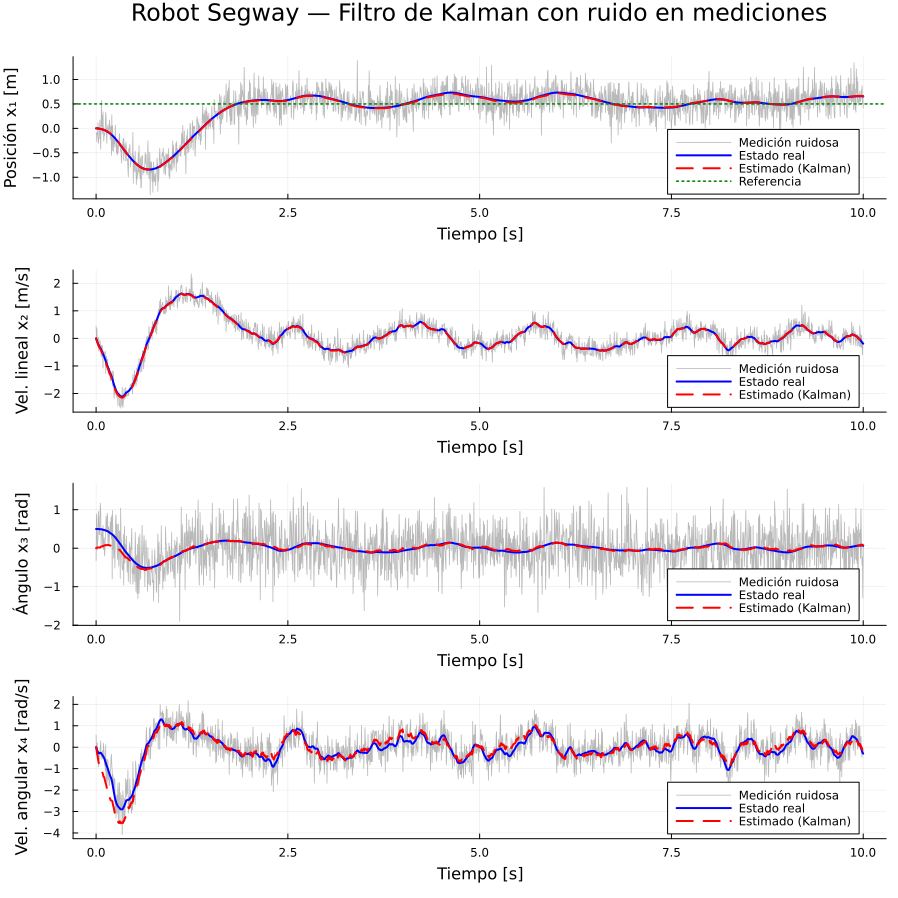

In [55]:
# ── Gráficas: estados reales, estimados y medidos (Robot) ──
etiq_r  = [L"x_1\ [m]" L"x_2\ [m/s]" L"x_3\ [rad]" L"x_4\ [rad/s]"]
ylab_r  = ["Posición x₁ [m]", "Vel. lineal x₂ [m/s]",
            "Ángulo x₃ [rad]", "Vel. angular x₄ [rad/s]"]

p_rob_k = plot(layout=(4,1), size=(900, 900),
               plot_title="Robot Segway — Filtro de Kalman con ruido en mediciones")

for i in 1:n_r
    plot!(p_rob_k[i], t_vec_r, Y_med_r[i, :],
          label="Medición ruidosa", color=:gray, alpha=0.55, lw=0.8)
    plot!(p_rob_k[i], t_vec_r, X_real_r[i, :],
          label="Estado real", color=:blue, lw=2)
    plot!(p_rob_k[i], t_vec_r, X_hat_r[i, :],
          label="Estimado (Kalman)", color=:red, lw=2, ls=:dash)
    ylabel!(p_rob_k[i], ylab_r[i])
    xlabel!(p_rob_k[i], "Tiempo [s]")
end

hline!(p_rob_k[1], [r_val_r], ls=:dot, color=:green, label="Referencia", lw=1.5)
display(p_rob_k)


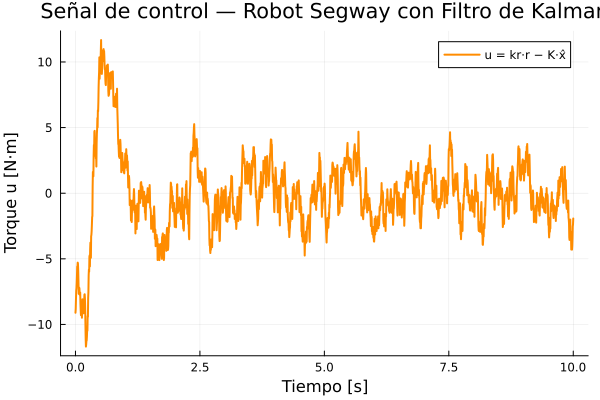

In [43]:
# ── Señal de control con Filtro de Kalman
plot(t_vec_r, U_r,
     xlabel="Tiempo [s]", ylabel="Torque u [N·m]",
     title="Señal de control — Robot Segway con Filtro de Kalman",
     label="u = kr·r − K·x̂", lw=2, color=:darkorange)


---
## Actividad 2: Sintonización del Filtro de Kalman

El desempeño del Filtro de Kalman depende de la elección de $Q$ y $R$.

**Experimente con los siguientes casos y compare los resultados:**

| Caso | Interpretación | Efecto esperado |
|------|----------------|-----------------|
| $Q \gg R$ | Se confía más en el sensor | Estimación más rápida, más ruidosa |
| $Q \ll R$ | Se confía más en el modelo | Estimación más suave, más lenta |
| $Q = R$   | Confianza balanceada | Término medio |

** En la práctica, $Q$ y $R$ se estiman a partir de datos experimentales o se sintonizan iterativamente.


In [ ]:
# ========================
# ACTIVIDAD 2: Sintonización — modifique Q_r y R_r y compare

# Caso A: Mayor confianza en sensores (Q >> R)
Q_A = Diagonal([1.0,  1.0,  5.0,  10.0])
R_A = Diagonal([0.01, 0.01, 0.01,  0.01])

# Caso B: Mayor confianza en el modelo (Q << R)
Q_B = Diagonal([0.0001, 0.001, 0.001, 0.005])
R_B = Diagonal([5.0,    5.0,   10.0,  20.0])
